In [1]:
# Setup: add project root
import sys
import os
import logging

# Configure logging to display in notebook
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s',
    handlers=[logging.StreamHandler(sys.stdout)]
)

sys.path.insert(0, '..')

from src.orchestrator import Orchestrator
from src.context.context_factory import create_context
BASE = os.path.abspath(os.path.join('..'))

print("Imports OK")

Imports OK


In [ ]:
from src.context.context_factory import create_context
save_path = os.path.join(BASE,"data/results/single_paper_results/agronomyjournal.csv")
folder_source = os.path.join(BASE, 'data/paper_to_extract/Agronomy Journal - 2021 - Hegstad - Agronomic and efficacy evaluations of oxathiapiprolin as a soybean seed treatment_formatted.md')


In [4]:
results2source_map = {
    "agronomyjournal": "Agronomy Journal - 2021 - Hegstad - Agronomic and efficacy evaluations of oxathiapiprolin as a soybean seed treatment_formatted.md",
    "assessmentofmaizegrowth.csv": "Assessment of Maize Growth and Development with High- and Medium-Resolution Remote Sensing Products_formatted.md",
    "bhadra2024.csv": "Bhadra 等 - 2024 - End-to-end 3D CNN for plot-scale soybean yield prediction using multitemporal UAV-based RGB images_formatted.md",
    "combined.csv": "Combined Spectral and Spatial Modeling of Corn Yield Based on Aerial Images and Crop Surface Models Acquired with an Unmanned Aircraft System_formatted.md",
    "damageassessment.csv": "Damage Assessment of Rice Crop after Toluene Exposure Based on the Vegetation Index (VI) and UAV Multispectral Imagery_formatted.md",
}

In [6]:
import pandas as pd
from sentence_transformers import SentenceTransformer, util


def compare_result_to_ground_truth(
    result_csv_path: str,
    filename_key: str,
    ground_truth_csv_path: str = os.path.join(BASE, "data/yield_extraction_ground_truth.csv"),
    model_name: str = "all-MiniLM-L6-v2",
    model: SentenceTransformer | None = None,
) -> pd.DataFrame:
    """
    Compare a single extracted results CSV against ground truth rows for the
    corresponding `filename` in `yield_extraction_ground_truth.csv`.

    - `filename_key` can be a key in `results2source_map` or an explicit
      ground-truth filename string.
    - Rows are aligned by normalized `yield_value`; for duplicates we keep the
      original order via a per-yield counter so we compare like-with-like.
    - For each matched pair, compute sentence-embedding similarity per shared
      column (excluding yield/matching helpers) and report the mean similarity
      across those columns.

    Returns a DataFrame with per-row similarity plus counts of unmatched rows.
    """
    target_filename = results2source_map.get(filename_key, filename_key)

    res_df = pd.read_csv(result_csv_path).copy()
    gt_df = pd.read_csv(ground_truth_csv_path).copy()
    gt_df = gt_df[gt_df["filename"] == target_filename].copy()

    if gt_df.empty:
        raise ValueError(f"No ground-truth rows found for filename: {target_filename}")

    # Normalize yield strings for matching and keep order for duplicates.
    res_df["yield_norm"] = res_df["yield_value"].astype(str).str.strip().str.lower()
    gt_df["yield_norm"] = gt_df["yield_value"].astype(str).str.strip().str.lower()
    res_df["match_id"] = res_df.groupby("yield_norm").cumcount()
    gt_df["match_id"] = gt_df.groupby("yield_norm").cumcount()

    merged = res_df.merge(
        gt_df,
        on=["yield_norm", "match_id"],
        suffixes=("_res", "_gt"),
    )

    if merged.empty:
        raise ValueError(
            "No overlapping rows found when matching on normalized yield_value. "
            "Check that the yields line up between the result CSV and ground truth."
        )

    # Determine comparable columns by name (exclude helpers).
    shared_cols = sorted(
        (set(res_df.columns) - {"yield_value", "yield_norm", "match_id"})
        & (set(gt_df.columns) - {"filename", "yield_value", "yield_norm", "match_id"})
    )
    if not shared_cols:
        raise ValueError("No shared columns to compare aside from yield_value.")

    if model is None:
        model = SentenceTransformer(model_name)

    sim_cols: list[str] = []
    for col in shared_cols:
        res_vals = merged[f"{col}_res"].fillna("").astype(str).tolist()
        gt_vals = merged[f"{col}_gt"].fillna("").astype(str).tolist()
        emb_res = model.encode(res_vals, convert_to_numpy=True)
        emb_gt = model.encode(gt_vals, convert_to_numpy=True)
        sim = util.cos_sim(emb_res, emb_gt).diagonal().tolist()
        sim_col = f"sim_{col}"
        merged[sim_col] = sim
        sim_cols.append(sim_col)

    merged["mean_similarity"] = merged[sim_cols].mean(axis=1)
    merged["target_filename"] = target_filename

    # Unmatched counts help track missing/extra rows.
    merged.attrs["unmatched_results_rows"] = len(res_df) - len(merged)
    merged.attrs["unmatched_ground_truth_rows"] = len(gt_df) - len(merged)

    # Human-friendly printout.
    print(f"Compared against filename: {target_filename}")
    print(f"Matched rows: {len(merged)}")
    print(f"Unmatched rows in result CSV: {merged.attrs['unmatched_results_rows']}")
    print(f"Unmatched rows in ground truth: {merged.attrs['unmatched_ground_truth_rows']}")
    for idx, row in merged.iterrows():
        print("-" * 60)
        print(f"Yield value: {row['yield_value_res']} (res) vs {row['yield_value_gt']} (gt)")
        print(f"Similarity mean across {len(shared_cols)} fields: {row['mean_similarity']:.3f}")
        print(
            "Field sims: "
            + ", ".join(f"{c.replace('sim_', '')}: {row[c]:.3f}" for c in sim_cols)
        )

    return merged[
        ["target_filename", "yield_value_res", "yield_value_gt", "mean_similarity", *sim_cols]
    ]


# Example usage (uncomment and adjust filename_key/result_csv_path to run):
# compare_result_to_ground_truth(
#     result_csv_path=os.path.join(BASE, "data/results/single_paper_results/damageassessment.csv"),
#     filename_key="damageassessment.csv",
# )

In [12]:
# Example usage (uncomment and adjust filename_key/result_csv_path to run):
sim_df = compare_result_to_ground_truth(
    result_csv_path=os.path.join(BASE, "data/results/single_paper_results/assessmentofmaizegrowth.csv"),
    filename_key="assessmentofmaizegrowth.csv",
)

2026-02-05 09:00:16,932 - sentence_transformers.SentenceTransformer - INFO - Use pytorch device_name: cpu
2026-02-05 09:00:16,933 - sentence_transformers.SentenceTransformer - INFO - Load pretrained SentenceTransformer: all-MiniLM-L6-v2


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

...

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Compared against filename: Assessment of Maize Growth and Development with High- and Medium-Resolution Remote Sensing Products_formatted.md
Matched rows: 4
Unmatched rows in result CSV: 0
Unmatched rows in ground truth: 0
------------------------------------------------------------
Yield value: 15,300 kg ha−1 (res) vs 15,300 kg ha−1 (gt)
Similarity mean across 6 fields: 0.759
Field sims: Soil_property: 0.915, Tillage: 0.469, Treatment: 0.254, crop_type: 1.000, location: 0.914, year: 1.000
------------------------------------------------------------
Yield value: 13,900 kg ha−1 (res) vs 13,900 kg ha−1 (gt)
Similarity mean across 6 fields: 0.761
Field sims: Soil_property: 0.915, Tillage: 0.469, Treatment: 0.268, crop_type: 1.000, location: 0.914, year: 1.000
------------------------------------------------------------
Yield value: 16,674 kg ha−1 (res) vs 16,674 kg ha−1 (gt)
Similarity mean across 6 fields: 0.705
Field sims: Soil_property: 0.876, Tillage: 0.280, Treatment: 0.184, crop_type

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


def plot_similarity_bars(
    sim_df: pd.DataFrame,
    columns_to_plot: list[str] | None = None,
    title: str | None = None,
    figsize: tuple[int, int] = (12, 6),
    bar_width: float = 0.18,
    group_spacing: float = 0.6,
    group_by: str = "row",
    bar_color: str = "#4C78A8",
    alpha: float = 1.0,
):
    """
    Plot grouped bar chart for similarity columns in `sim_df`.

    group_by="row" (default): each row in `sim_df` is a group; bars inside are
    the selected columns (original behaviour).

    group_by="column": each selected column is a group; bars inside are the
    rows (so all bars for the same column stay together).
    """
    if columns_to_plot is None:
        columns_to_plot = [c for c in sim_df.columns if c.startswith("sim_")]
        if "mean_similarity" in sim_df.columns:
            columns_to_plot = ["mean_similarity"] + columns_to_plot

    if not columns_to_plot:
        raise ValueError("No similarity columns to plot.")

    n_rows = len(sim_df)
    n_cols = len(columns_to_plot)

    fig, ax = plt.subplots(figsize=figsize)

    if group_by == "row":
        x_positions = np.arange(n_rows) * (n_cols * bar_width + group_spacing)
        for i, col in enumerate(columns_to_plot):
            offsets = x_positions + i * bar_width
            ax.bar(offsets, sim_df[col], width=bar_width, color=bar_color, alpha=alpha)
        ax.set_xticks(x_positions + (n_cols - 1) * bar_width / 2)
        ax.set_xticklabels(
            sim_df.get("yield_value_res", sim_df.index).astype(str), rotation=45, ha="right"
        )
    elif group_by == "column":
        x_positions = np.arange(n_cols) * (n_rows * bar_width + group_spacing)
        row_labels = sim_df.get("yield_value_res", sim_df.index).astype(str).tolist()
        for i, row_idx in enumerate(sim_df.index):
            offsets = x_positions + i * bar_width
            ax.bar(
                offsets,
                sim_df.loc[row_idx, columns_to_plot],
                width=bar_width,
                color=bar_color,
                alpha=alpha,
            )
        ax.set_xticks(x_positions + (n_rows - 1) * bar_width / 2)
        ax.set_xticklabels(columns_to_plot, rotation=45, ha="right")
        if n_rows:
            ax.legend(
                handles=[
                    plt.Line2D([0], [0], marker="s", linestyle="", color=bar_color, markersize=10)
                ],
                labels=["bars"],
                loc="upper left",
                bbox_to_anchor=(1.04, 1),
                frameon=False,
            )
    else:
        raise ValueError("group_by must be 'row' or 'column'.")

    ax.set_ylabel("Cosine similarity")
    if title:
        ax.set_title(title)
    ax.set_ylim(0, 1)
    plt.tight_layout()
    return ax


# Example plotting (assuming `sim_df` from compare_result_to_ground_truth):
# ax = plot_similarity_bars(sim_df, title="Similarity by yield row")
# plt.show()


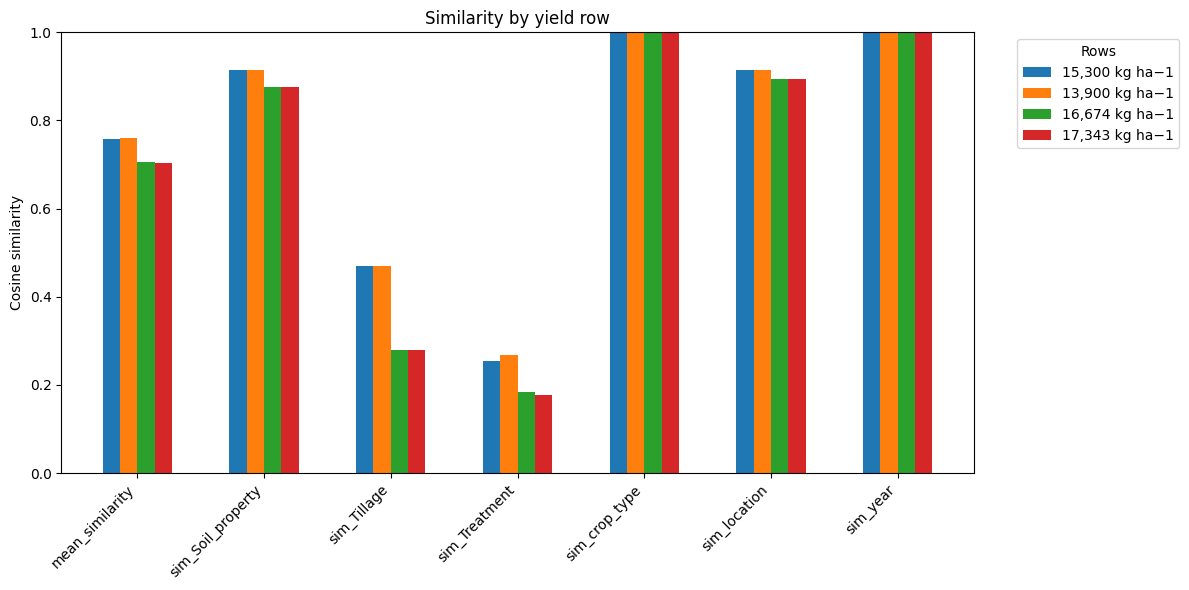

In [19]:
ax = plot_similarity_bars(sim_df, title="Similarity by yield row", group_by="column")
plt.show()